In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## I - Modèle de taux

1) Simulation d'un modèle de taux 

Pour se familiariser avec l'implémentation des calculs pour la simulation des processus stochastiques.
On ne considère pas le terme déterministe dans un premier temps (considéré nul)

In [3]:
# Paramètres du modèle G2++
r0 = 0.03  # taux court initial
T = 50  # horizon de simulation en années
N = 5000  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

# Paramètres du modèle (à ajuster)
a, b = 0.1, 0.3  # coefficients de régression vers la moyenne
sigma, eta = 0.02, 0.01  # volatilités
rho = 0.5  # corrélation entre W1 et W2

# Observé
f_0_T = 0.03  # taux court initial

In [4]:
# Génération des mouvements browniens corrélés W1 et W2
dW1 = np.random.normal(0, np.sqrt(dt), N)
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

W1 = np.concatenate(([0], np.cumsum(dW1)))
W2 = np.concatenate(([0], np.cumsum(dW2)))



- Solution analytique des processus

Les processus $x(t)$ et $y(t)$ du modèle G2++ suivent les équations différentielles stochastiques :

$$
dx(t) = -a x(t) dt + \sigma dW_1(t)
$$

$$
dy(t) = -b y(t) dt + \eta dW_2(t)
$$

où $W_{1}(t)$ et $W_{2}(t)$ sont des mouvements browniens corrélés avec un coefficient $\rho$.

### **Solution intégrée des EDS**

En intégrant ces équations, on obtient les solutions analytiques :

$$
x(t) = x(0) e^{-a t} + \sigma \int_0^t e^{-a (t-s)} dW_1(s)
$$

$$
y(t) = y(0) e^{-b t} + \eta \int_0^t e^{-b (t-s)} dW_2(s)
$$

Après discrétisation sur un pas de temps $\Delta t$, nous utilisons :

$$
x_{i+1} = x_i e^{-a \Delta t} + \sigma \sqrt{\frac{1 - e^{-2a \Delta t}}{2a}} Z_1
$$

$$
y_{i+1} = y_i e^{-b \Delta t} + \eta \sqrt{\frac{1 - e^{-2b \Delta t}}{2b}} Z_2
$$

où $ Z_1 \sim \mathcal{N}(0,1) $ et $ Z_2 \sim \mathcal{N}(0,1) $ sont des variables normales centrées réduites, générées de manière corrélée :

$$
Z_2 = \rho Z_1 + \sqrt{1 - \rho^2} \cdot \mathcal{N}(0,1)
$$


In [5]:
# Simulation des processus x(t) et y(t)
x = np.zeros(N + 1)
y = np.zeros(N + 1)

for t in range(1, N + 1):
    x[t] = x[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * np.random.normal(0, 1)
    y[t] = y[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * np.random.normal(0, 1)



In [6]:
# Simulation de theta(t) (simplifiée sans courbe de taux initiale)
theta = np.zeros(N + 1)  # Pour l'instant, on prend une approximation à zéro

# Calcul du taux r(t)
r = x + y + theta



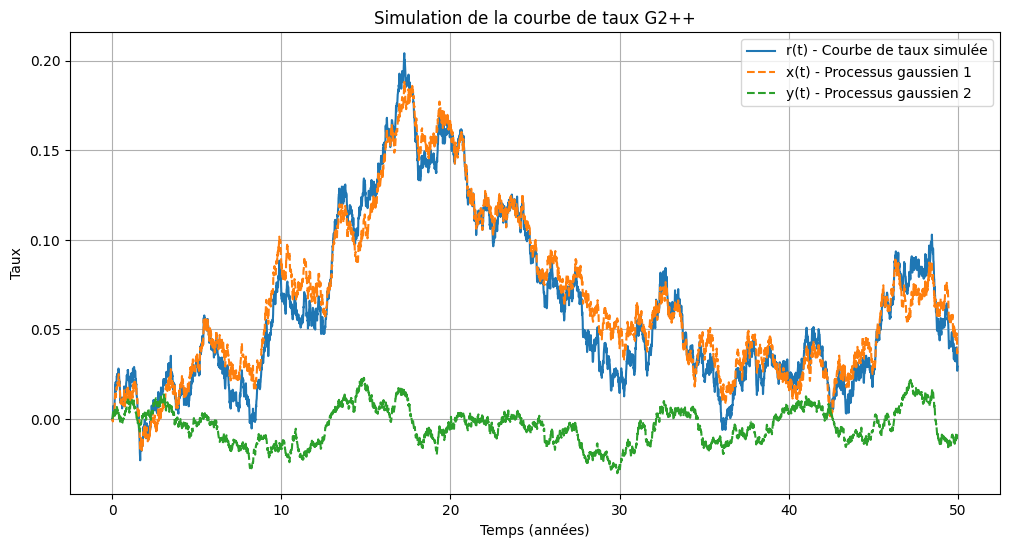

In [7]:
# Affichage des courbes
plt.figure(figsize=(12, 6))
plt.plot(t_grid, r, label='r(t) - Courbe de taux simulée')
plt.plot(t_grid, x, label='x(t) - Processus gaussien 1', linestyle='dashed')
plt.plot(t_grid, y, label='y(t) - Processus gaussien 2', linestyle='dashed')
plt.xlabel('Temps (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++')
plt.grid()
plt.show()

# Stockage des résultats dans un DataFrame
df_rates = pd.DataFrame({'Temps': t_grid, 'r(t)': r, 'x(t)': x, 'y(t)': y})


2) Ajout du terme déterministe

In [8]:
data = pd.ExcelFile("Input_GSE.xlsx")
data.sheet_names

['Cap Volatility', 'EIOPA Rate', 'EURIBOR Rate', 'Call Euro Stoxx 50']

In [9]:
courbe_taux = pd.read_excel(data, sheet_name="EIOPA Rate", usecols=[0, 1])
courbe_taux.dropna(inplace=True)

courbe_taux.head()

,Maturity,Rate
0,1,0.02236
1,2,0.02093
2,3,0.02093
3,4,0.02120
4,5,0.02142


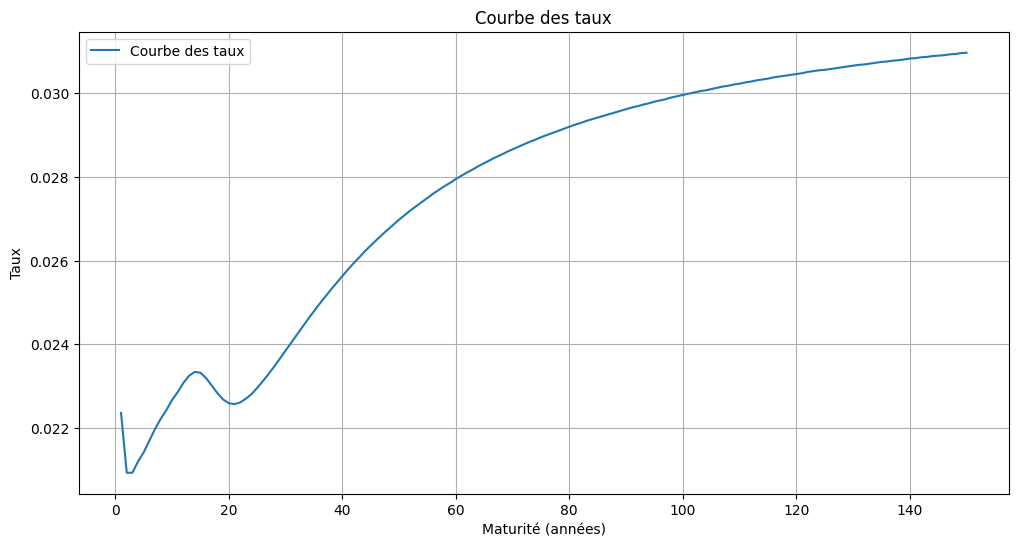

In [10]:
# Plot the yield curve
plt.figure(figsize=(12, 6))
plt.plot(courbe_taux['Maturity'], courbe_taux['Rate'], label='Courbe des taux')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Courbe des taux')
plt.grid()
plt.show()

On a besoin pour coller à la courbe des taux de calculer les taux forward f(0,t)

In [11]:
maturities = courbe_taux["Maturity"].values
zero_coupon_rates = courbe_taux["Rate"].values

Methode NSS pour calculer le taux forward :  
$$
f(0,t) = \beta_0 + \beta_1 \cdot \alpha_1(t) + \beta_2 \cdot \alpha_2(t) + \beta_3 \cdot \alpha_3(t)
$$

avec :

$$
\alpha_1(t) = \frac{1 - e^{-t/\tau_1}}{t/\tau_1}
$$

$$
\alpha_2(t) = \alpha_1(t) - e^{-t/\tau_1}
$$

$$
\alpha_3(t) = \frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}
$$


In [12]:
from scipy.optimize import minimize

# Fonction qui calcule le taux forward f(0,t) selon le modèle NSS
def forward_0t(t, params):
    """
    Modèle de Nelson-Siegel-Svensson pour la courbe de taux forward instantanée.
    
    Arguments:
    t : float ou np.array : maturité en années
    params : list ou np.array : paramètres [beta0, beta1, beta2, beta3, tau1, tau2]
    
    Retourne:
    f(0,t) : taux forward instantané
    """

    beta0, beta1, beta2, beta3, tau1, tau2 = params
    
    alpha1 = np.where(t == 0, 1, (1 - np.exp(-t / tau1)) / (t / tau1))
    alpha2 = alpha1 - np.exp(-t / tau1)
    alpha3 = np.where(t == 0, 1, (1 - np.exp(-t / tau2)) / (t / tau2)) - np.exp(-t / tau2)
    return beta0 + beta1 * alpha1 + beta2 * alpha2 + beta3 * alpha3


Minimisation par somme des écarts au carré

In [13]:
# Fonction d'objectif à minimiser pour calibrer les paramètres NSS
def NSS_objectif(params, maturities, rates):
    """
    Fonction d'erreur quadratique pour l'optimisation NSS.
    """
    return np.sum((forward_0t(maturities, params) - rates) ** 2)

In [14]:
# Estimation des paramètres initiaux (valeurs de départ pour l'optimisation)
initial_params = [0.03, -0.02, 0.02, -0.01, 2.0, 10.0]

# Exécution de l'optimisation
res = minimize(NSS_objectif, x0=initial_params, args=(maturities, zero_coupon_rates), method="Nelder-Mead")

# Récupération des paramètres optimisés
params_NSS = res.x

# Calcul de la courbe des taux forward calibrée avec les paramètres NSS optimisés
taux_forward_NSS = forward_0t(maturities, params_NSS)

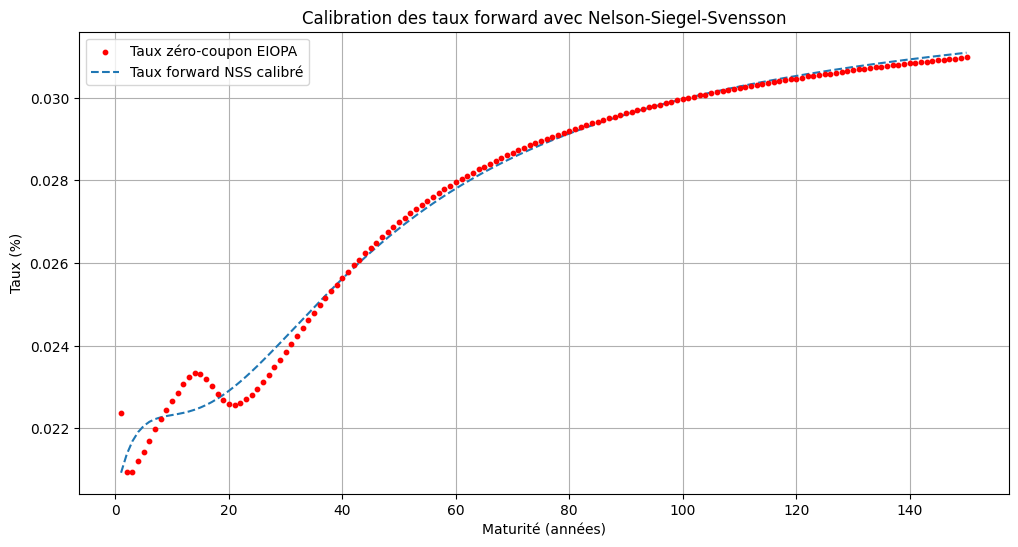

In [15]:
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.scatter(maturities, zero_coupon_rates, color='red', label="Taux zéro-coupon EIOPA", zorder=3, s=10)
plt.plot(maturities, taux_forward_NSS, label="Taux forward NSS calibré", linestyle='dashed', zorder=2)
plt.xlabel("Maturité (années)")
plt.ylabel("Taux (%)")
plt.legend()
plt.title("Calibration des taux forward avec Nelson-Siegel-Svensson")
plt.grid()
plt.show()

# Stockage des résultats
df_taux_forward = pd.DataFrame({'Maturité': maturities, 'Taux Zéro-Coupon': zero_coupon_rates, 'Taux Forward NSS': taux_forward_NSS})

ou par interpolation par les splines cubiques

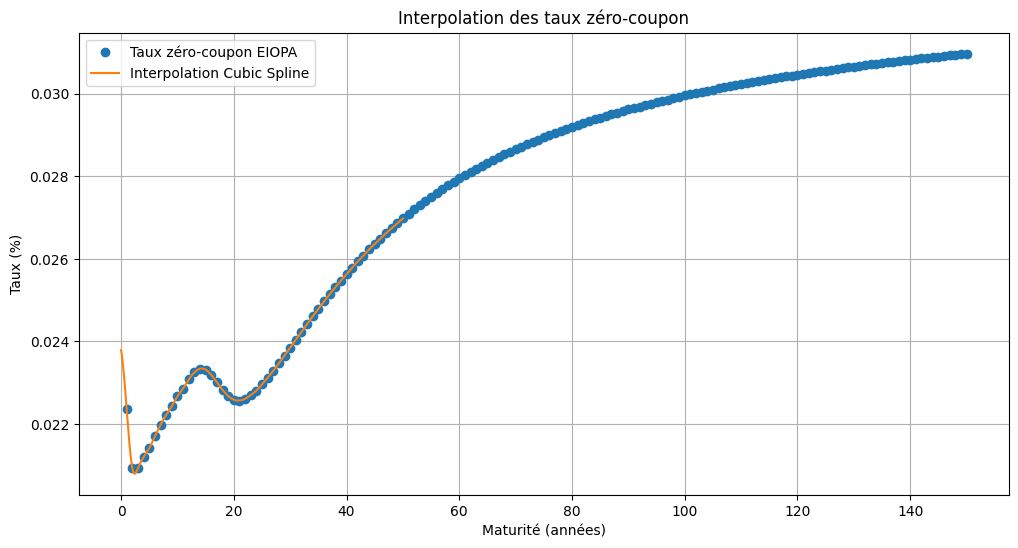

In [16]:
from scipy.interpolate import CubicSpline

# Interpolation des taux zéro-coupon
assert np.all(np.diff(maturities) > 0), "Les maturités doivent être strictement croissantes."

interpolateur_zero_coupon = CubicSpline(maturities, zero_coupon_rates, bc_type='natural')

# Calcul des taux zéro-coupon interpolés
maturities_interpol = t_grid
zero_coupon_rates_interpol = interpolateur_zero_coupon(maturities_interpol)

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities, zero_coupon_rates, 'o', label='Taux zéro-coupon EIOPA')
plt.plot(maturities_interpol, zero_coupon_rates_interpol, label='Interpolation Cubic Spline')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux (%)')
plt.legend()
plt.title('Interpolation des taux zéro-coupon')
plt.grid()


#### Calcul du Taux Forward Instantané \( f(0,T) \) à partir de la Courbe Interpolée

Lorsque l'on dispose d'une **courbe interpolée des taux zéro-coupon** $ r(0,T) $, le **taux forward instantané** est donné par :

$$
f(0,T) = r(0,T) + T \frac{d r(0,T)}{dT}
$$

où :
- $ r(0,T) $ est le taux zéro-coupon interpolé à maturité $ T $.
- $ \frac{d r(0,T)}{dT} $ est la dérivée du taux zéro-coupon par rapport à $ T $, calculée numériquement.



In [ ]:
def calculate_forward_rates(maturities, zero_coupon_rates, dr_dt_values):
    """
    Calcule les taux forward instantanés f(0,T) pour les maturités données.

    Arguments :
    maturities : np.array : Maturités en années
    zero_coupon_rates_interpol : np.array : Taux zéro-coupon interpolés
    dr_dt_values : np.array : Dérivées des taux zéro-coupon interpolés

    Retourne :
    forward_rates : np.array : Taux forward instantanés f(0,T)
    """
    forward_rates = zero_coupon_rates + maturities * dr_dt_values
    return forward_rates

# Calcul des dérivées des taux zéro-coupon interpolés
dr_dt = interpolateur_zero_coupon.derivative()
dr_dt_values = dr_dt(t_grid[1:])
zero_coupon_rates_interpol = interpolateur_zero_coupon(t_grid[1:])

# Calcul des taux forward pour les maturités données
forward_rates = calculate_forward_rates(t_grid[1:], zero_coupon_rates_interpol, dr_dt_values)

# Affichage des résultats
df_forward_rates = pd.DataFrame({'Maturité': t_grid[1:], 'Taux Forward f(0,T)': forward_rates})


df_forward_rates

NameError: name 'interpolateur_zero_coupon' is not defined

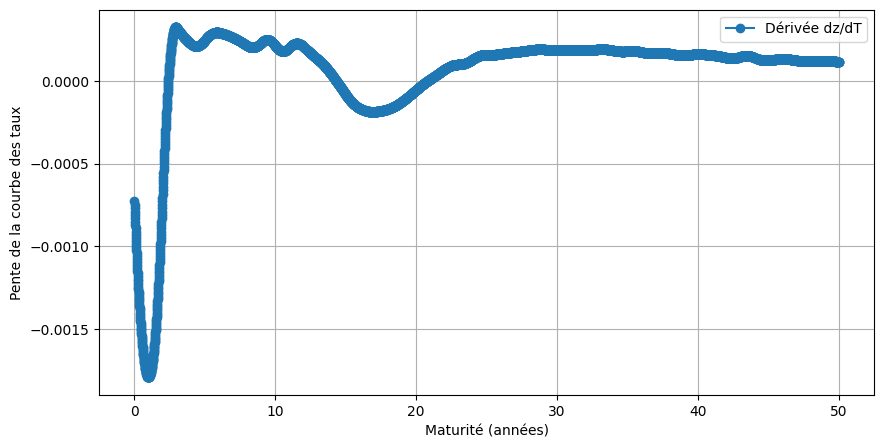

In [170]:
plt.figure(figsize=(10,5))
plt.plot(t_grid[1:], dr_dt_values, marker="o", label="Dérivée dz/dT")
plt.xlabel("Maturité (années)")
plt.ylabel("Pente de la courbe des taux")
plt.legend()
plt.grid()
plt.show()


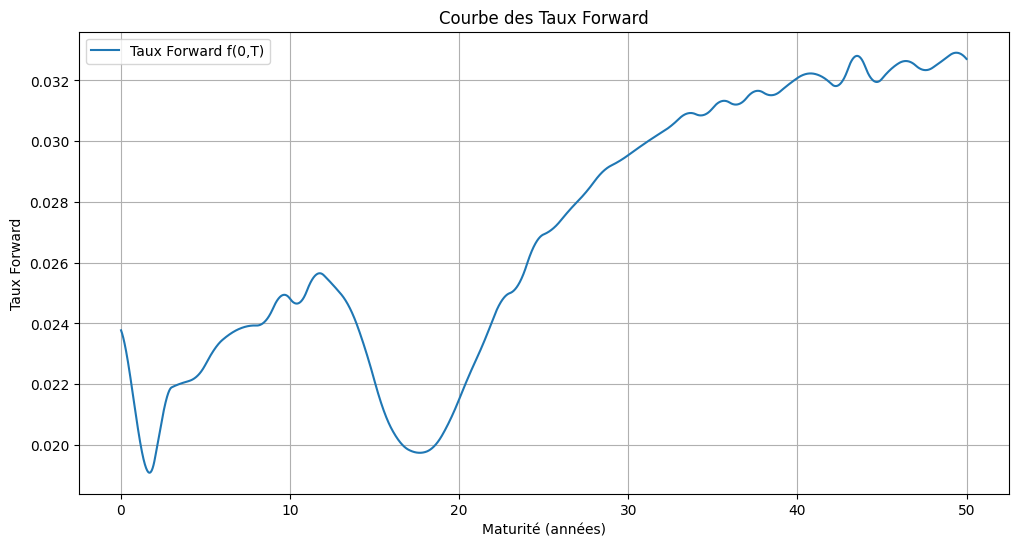

In [171]:
# Tracé de la courbe des taux forward
plt.figure(figsize=(12, 6))
plt.plot(df_forward_rates["Maturité"], df_forward_rates["Taux Forward f(0,T)"], label='Taux Forward f(0,T)')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux Forward')
plt.legend()
plt.title('Courbe des Taux Forward')
plt.grid()
plt.show()

Calcul de la partie déterministe avec la formule :  
$$
\theta(t) = \frac{\partial f(0,t)}{\partial t} + a f(0,t) + b f(0,t) 
- \frac{\sigma^2}{2a} (1 - e^{-2at}) 
- \frac{\eta^2}{2b} (1 - e^{-2bt}) 
- \frac{\rho \sigma \eta}{a+b} (1 - e^{-(a+b)t})
$$


In [172]:
# Interpolation des taux forward
interpolateur_forward = CubicSpline(t_grid[1:], forward_rates, bc_type='natural')

# Calcul des dérivées des taux forward interpolés
dr_dt_forward = interpolateur_forward.derivative()
dr_dt_forward_values = dr_dt_forward(t_grid[1:])


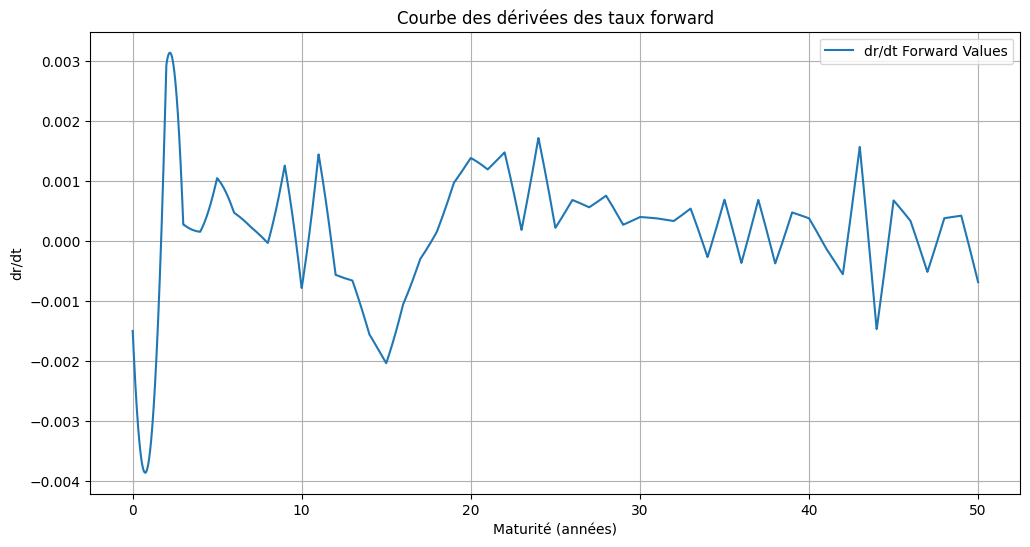

In [173]:
plt.figure(figsize=(12, 6))
plt.plot(t_grid[1:], dr_dt_forward_values, label='dr/dt Forward Values')
plt.xlabel('Maturité (années)')
plt.ylabel('dr/dt')
plt.legend()
plt.title('Courbe des dérivées des taux forward')
plt.grid()
plt.show()

In [174]:
theta = [r0]
for t_idx, t in enumerate(t_grid[1:]):
    
    taux_forward = forward_rates[t_idx]

    # Calcul des termes correctifs
    terme1 = (sigma**2 / (2 * a**2)) * ((1 - np.exp(- a * t))**2)
    terme2 = (eta**2 / (2 * b**2)) * ((1 - np.exp(- b * t))**2)
    terme3 = (rho * sigma * eta / (a + b)) * (1 - np.exp(- b * t)) * (1 - np.exp(- a * t))

    # Calcul de θ(t)
    theta_t =  taux_forward + terme1 + terme2 + terme3

    theta.append(theta_t)


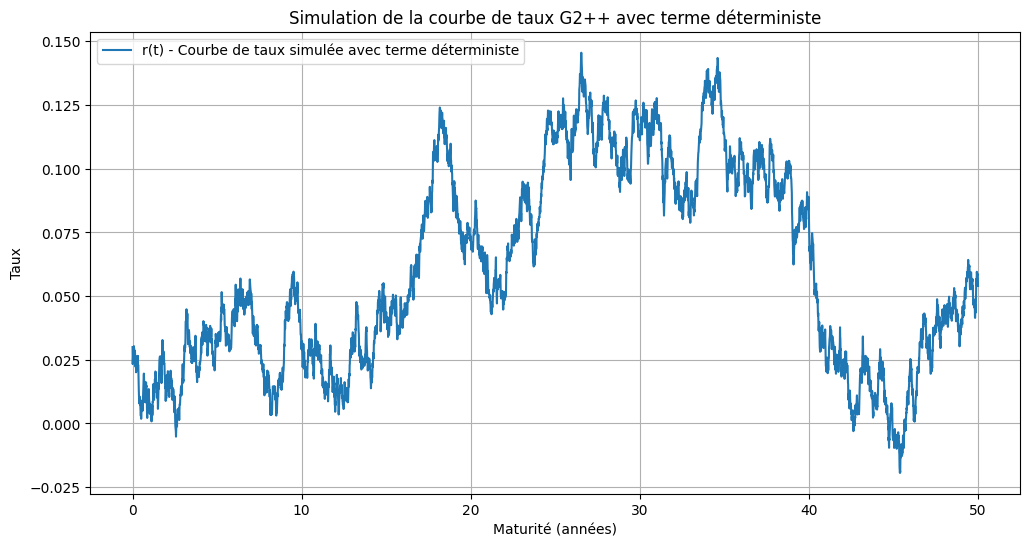

In [175]:
r = {t : x[t_idx] + y[t_idx] + theta[t_idx] for t_idx, t in enumerate(t_grid)}
plt.figure(figsize=(12, 6))
plt.plot(list(r.keys()), list(r.values()), label='r(t) - Courbe de taux simulée avec terme déterministe')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++ avec terme déterministe')
plt.grid()
plt.show()

### Pricing d'une obligation Zéro-Coupon

1) A partir des valeurs du marché

5001
5001


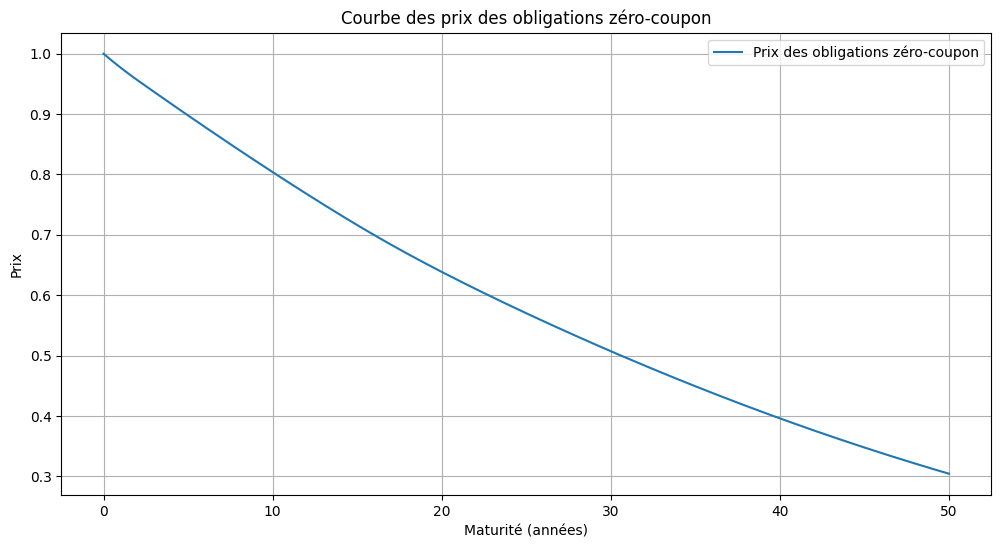

In [176]:
def zero_coupon_price_marche(maturity):
    primitive_zero_coupon = interpolateur_zero_coupon.antiderivative()

    # Calcul de l'intégrale de 0 à T
    integrale_r_T = primitive_zero_coupon(maturity) - primitive_zero_coupon(0)

    # Calcul du prix de l'obligation zéro-coupon
    P_T = np.exp(-integrale_r_T)
    
    return P_T

# Calcul des prix zéro-coupon à partir des taux observés/interpolés
prices_zero_coupon_marche = {T : zero_coupon_price_marche(T) for T in t_grid}
print(len(prices_zero_coupon_marche))
print(len(maturities_interpol))
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, prices_zero_coupon_marche.values(), label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

interpolateur_prices_zero_coupon_marche = CubicSpline(maturities_interpol, list(prices_zero_coupon_marche.values()), bc_type='natural')
derivee_prices_zero_coupon_marche = interpolateur_prices_zero_coupon_marche.derivative()


2) Pricing d'une Obligation Zéro-Coupon \( P(t, T) \) sous le Modèle G2++
 
- Formule de $ P(t, T) $ sous G2++

Le prix d’une obligation zéro-coupon sous G2++ est donné par :

$$
P(t,T) = A(t,T)e^{-B(t,T,a)x(t)-B(t,T,b)y(t)}
$$

où :
- $ A(t,T) $ et $ B(t,T) $ sont des fonctions explicites dépendant des paramètres du modèle.
- $ r_t $ est le **taux court** à l'instant $ t $.
---

- Expressions de $ A(t,T) $ et $ B(t,T) $

$$
B(t,T,z) = \frac{1 - e^{-z (T-t)}}{z}
$$

$$
A(t,T) = \frac{P(0,T)}{P(0,t)} \exp\left(\frac{1}{2}\left(V(t,T) - V(0,T) + V(0,t)\right)\right)
$$

avec les variances et covariances :

$
V_x(t,T) = \frac{\sigma^2}{a^2} \left[ T - t + \frac{2}{a} e^{-a(T - t)} - \frac{1}{2a} e^{-2a(T - t)} - \frac{3}{2a} \right]
$

$
V_y(t,T) = \frac{\eta^2}{b^2} \left[ T - t + \frac{2}{b} e^{-b(T - t)} - \frac{1}{2b} e^{-2b(T - t)} - \frac{3}{2b} \right]
$

$
V_xy(t,T) = \frac{2\rho\,\sigma\eta}{a b}\left(T - t - \frac{1 - e^{-a(T - t)}}{a} - \frac{1 - e^{-b(T - t)}}{b} - \frac{e^{-(a + b)(T - t)} - 1}{a + b}\right)
$



In [241]:
# Fonctions de calcul des facteurs de B(t, T, z)
def B(t, T, z):
    return (1 - np.exp(-z * (T - t))) / z


# Fonctions de calcul des variances et covariances
def var_x(t,T, a, sigma):
    return (sigma**2 / (a**2)) * ((T-t) + (2/a) * np.exp(- a * (T-t)) - (1/(2*a)) * np.exp(-2*a * (T-t)) - (3/(2*a)))

def var_y(t,T, b, eta):
    return (eta**2 / (b**2)) * ((T-t) + (2/b) * np.exp(- b * (T-t)) - (1/(2*b)) * np.exp(-2*b * (T-t)) - (3/(2*b)))

def cov_xy(t,T, a, b, sigma, eta, rho):
    return (2 * sigma * eta * rho / (a * b )) * ((T-t) - (( 1 - np.exp(- a * (T-t)) ) / a) - (( 1 - np.exp(- b * (T-t)) ) / b) - (np.exp(-(a + b) * (T-t)) - 1)/ (a + b))


def V(t,T, a, b, sigma, eta, rho):
    V_x = var_x(t,T, a, sigma)
    V_y = var_y(t,T, b, eta)
    V_xy = cov_xy(t,T, a, b, sigma, eta, rho)
    return V_x + V_y + V_xy

# Fonction de calcul des facteurs A(t, T, a, b, sigma, eta, rho)
def A(t, T, a, b, sigma, eta, rho, r):

    V_t_T = V(t, T, a, b, sigma, eta, rho)
    V_0_T = V(0, T, a, b, sigma, eta, rho)
    V_0_t = V(0, t, a, b, sigma, eta, rho)

    P_0_T = prices_zero_coupon_marche[T]
    P_0_t = prices_zero_coupon_marche[t]

    A_tT = (P_0_T/P_0_t)* np.exp(0.5 * (V_t_T - V_0_T + V_0_t))
    
    return A_tT

V_t_T = V(0, 0, a, b, sigma, eta, rho)
V_t_T

np.float64(-1.414426203003892e-19)

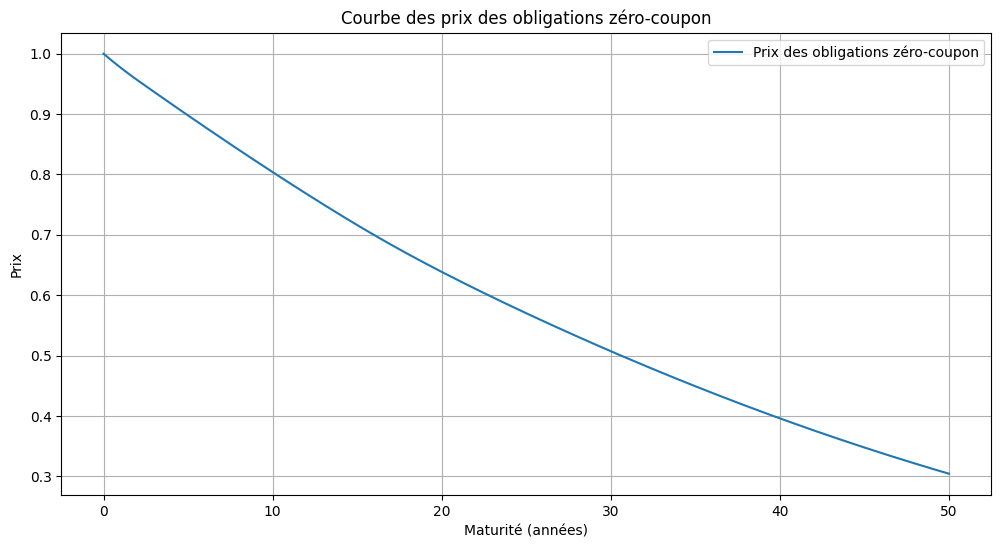

In [242]:
def prix_zero_coupon(t, T, a, b, sigma, eta, rho, x, y):
    A_tT = A(t, T, a, b, sigma, eta, rho, r)
    B_tT_a = B(t, T, a)
    B_tT_b = B(t, T, b)

    r_t = r[t]
    x_t = x[t]
    y_t = y[t]

    return A_tT * np.exp( - B_tT_a * x_t - B_tT_b  * y_t)

# Calcul des prix des obligations zéro-coupon P(0, T)
zero_coupon_prices = {T : prix_zero_coupon(0, T, a, b, sigma, eta, rho, x, y) for T in t_grid}

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, zero_coupon_prices.values(), label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

On peut maintenant calculer les taux forward définis par :
$$
f(t,T) = -\frac{\partial \ln(P(t,T))}{\partial T}
$$  
 - Pour le modèle marché

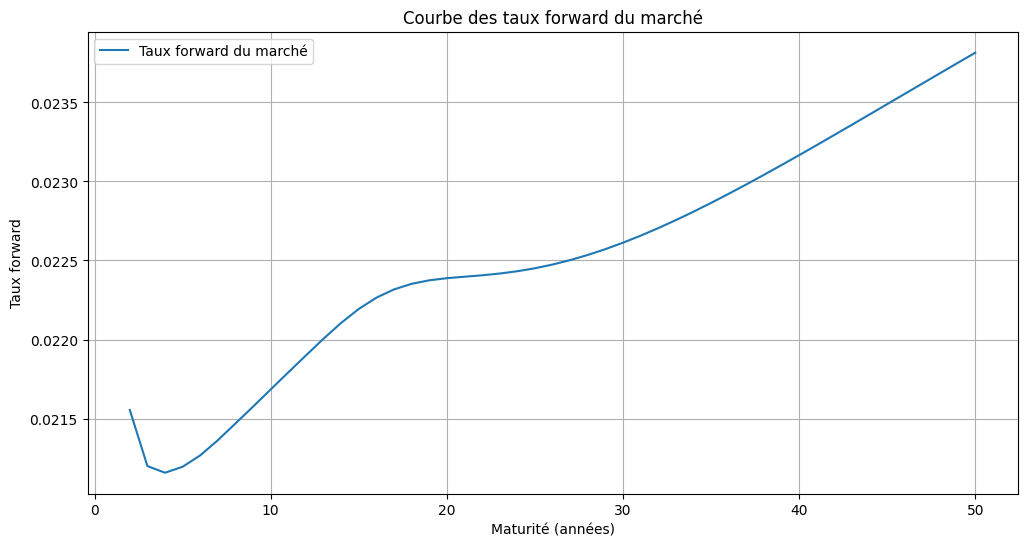

In [ ]:
def forward_rate_marche(t,T):
    fwr_m = (-np.log(prices_zero_coupon_marche[T])+np.log(prices_zero_coupon_marche[t]))/(T-t)
    return fwr_m

# Calcul des taux forward du marché f(1,T)
forward_rates_marche = {T : forward_rate_marche(1, T) for T in range(2, 51)}
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(forward_rates_marche.keys(), forward_rates_marche.values(), label='Taux forward du marché')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward')
plt.legend()
plt.title('Courbe des taux forward du marché')
plt.grid()
plt.show()

- Pour le modèle théorique
$$
f(t,T) = -\frac{\partial}{\partial T} \ln P(t,T) \\  
f(t,T) = -\frac{\partial}{\partial T} \ln A(t,T) + \frac{\partial B}{\partial T}(a, t, T) x(t) + \frac{\partial B}{\partial T}(b, t, T) y(t)
$$ 
pour le modèle théorique

In [ ]:
# Dérivée partielle de Vx par rapport à T
def dvar_x_dT(t, T, a, sigma):
    return (sigma**2 / (a**2)) * (1 - 2 * np.exp( - a * (T-t)) + np.exp(-2 * a * (T-t)) )

# Dérivée partielle de Vy par rapport à T
def dvar_y_dT(t,T, b, eta):
    return (eta**2 / (b**2)) * (1 - 2 * np.exp( - b * (T-t)) + np.exp(-2 * b * (T-t)) )

# Dérivée partielle de Vxy par rapport à T
def dcov_xy_dT(t,T, a, b, sigma, eta, rho):
    return (2 * sigma * eta * rho / (a * b )) * (1 + - np.exp(- a * (T-t))) + - np.exp(- b * (T-t)) + np.exp(-(a + b) * (T-t))



# Fonction dérivée de B(t, T)
def dB_dT(T, t, z):
    return np.exp(-z * (T - t))

# Fonction dérivée de A(t, T)
def dA_dT(T, t, a, b, sigma, eta, rho):
    dVx_dT = dvar_x_dT(t,T, a, sigma)
    dVy_dT = dvar_y_dT(t,T, b, eta)
    dVxy_dT = dcov_xy_dT(t,T, a, b, sigma, eta, rho)
    dV_t_T = dVx_dT + dVy_dT + dVxy_dT

    dVx_dT_0 = dvar_x_dT(0,T, a, sigma)
    dVy_dT_0 = dvar_y_dT(0,T, b, eta)
    dVxy_dT_0= dcov_xy_dT(0,T, a, b, sigma, eta, rho)
    dV_0_T = dVx_dT_0 + dVy_dT_0 + dVxy_dT_0
    db_dT = dB_dT(T,t,a)
    r_t = r[t]
    P_0_T = prix_zero_coupon(0, T, a, b, sigma, eta, rho, x, y)
    P_0_t = prix_zero_coupon(0, t, a, b, sigma, eta, rho, x, y)
    
    dP_0_T = derivee_prices_zero_coupon_marche(T)
    return (-np.log(P_0_T)+np.log(prices_zero_coupon_marche[t]))/(T-t) * A(t, T, a, b, sigma, eta, rho, r) + 0.5 * (dV_t_T - dV_0_T) * A(t, T, a, b, sigma, eta, rho, r)

# Fonction de taux forward f(t,T) sous G2++
def forward_rate_G2pp(t, T, a, b, sigma, eta, rho, x,y):
    if t == 0 :
        return f_0_T
    dA = dA_dT(T, t, a, b, sigma, eta, rho)
    dB_a = dB_dT(T, t, a)
    dB_b = dB_dT(T, t, b)
    r_t = r[t]
    rate = -( dA / A(t, T, a, b, sigma, eta, rho, r) ) + dB_a * x[t] + dB_b * y[t]
    return max(rate,0.0000001)



# Exemple : calcul du taux forward pour T=5 ans
t = 2  # Instant présent
T = 5  # Maturité en années
f_0_T = df_forward_rates.loc[df_forward_rates["Maturité"] == T, "Taux Forward f(0,T)"].values
forward_rate_G2pp(2,3,a,b,sigma,eta,rho,x,y)

np.float64(0.005169731364916996)

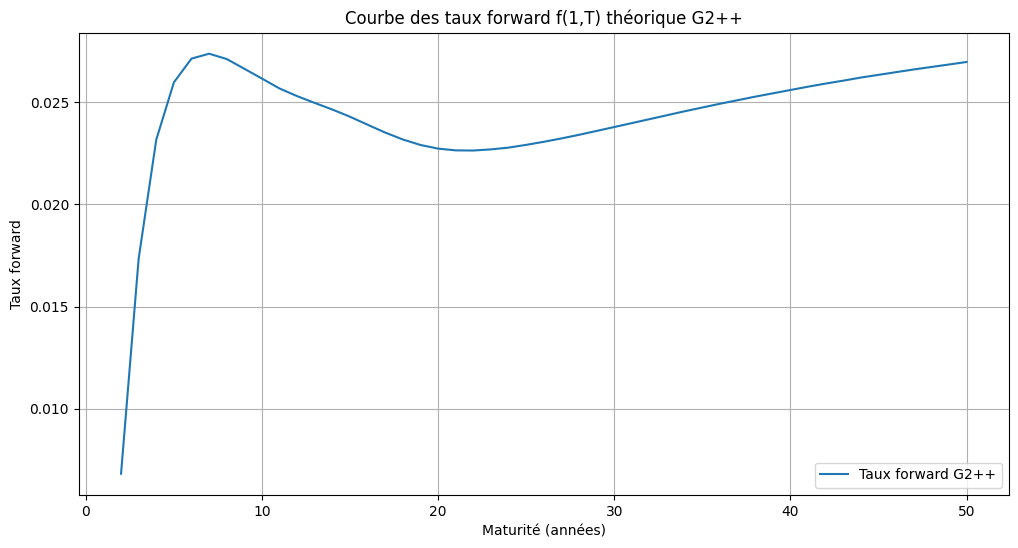

In [245]:
# Calcul des taux forward du marché f(1,T)
forward_rates_G2pp = {T : forward_rate_G2pp(1, T, a, b, sigma, eta, rho, x, y) for T in range(2, 51)}
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(forward_rates_marche.keys(), forward_rates_G2pp.values(), label='Taux forward G2++')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward')
plt.legend()
plt.title('Courbe des taux forward f(1,T) théorique G2++')
plt.grid()
plt.show()

3) Pricing de Cap

Quelle formule de pricing on utilise ?

#### 1. Formule de marché pour Pricer un Cap

Un **cap** peut être décomposé en une série de **caplets**, chacun correspondant à une option sur taux d'intérêt forward. La formule de Black est utilisée pour pricer chaque caplet :

$
Cpl(t, T_i, T_{i+1}, \tau_i, N, K) = N P(t, T_{i+1}) \tau_i \left( F(t, T_i, T_{i+1}) \Phi(d_1) - K \Phi(d_2) \right)
$

où :
- $P(t, T_{i+1})$ est le prix du zéro-coupon à l'instant $t$ pour l'échéance $T_{i+1}$,
- $F(t, T_i, T_{i+1})$ est le taux forward entre $T_i$ et $T_{i+1}$,
- $N$ est le nominal,
- $\tau_i$ est la fraction de l'année entre $T_i$ et $T_{i+1}$,
- $K$ est le taux d'exercice du cap,
- $\Phi$ est la fonction de répartition de la loi normale,
- $d_1$ et $d_2$ sont donnés par :

$
d_1 = \frac{\ln \left( \frac{F(t, T_i, T_{i+1})}{K} \right) + \frac{1}{2} \sigma^2 (T_{i+1} - t)}{\sigma \sqrt{T_{i+1} - t}}
$

$
d_2 = d_1 - \sigma \sqrt{T_{i+1} - t}
$

où $\sigma$ est la **volatilité implicite** du caplet.

Le prix total d’un cap est obtenu en sommant les prix des caplets :

$
C(t) = \sum_{i=1}^{n} Cpl(t, T_i, T_{i+1}, \tau_i, N, K)
$

---

#### 2. Formule théorique de pricing du Cap sous G2++

Dans un cadre plus théorique, notamment sous un modèle comme **G2++**, le prix d’un **cap** est obtenu en intégrant les paramètres du modèle pour estimer la volatilité effective du taux forward. Il est donné par la même formule :

$
Cap^{\text{Black}}(0, \mathcal{T}, \tau, N, K, \sigma_{a,b}) =
N \sum_{i=a+1}^{b} P(0, T_i) \tau_i \text{Bl}(K, F(0, T_{i-1}, T_i), v_i),
$

où **$ v_i $** la volatilité effective du taux forward est définie par :

- $
v_i = \sigma_{a,b} \sqrt{T_{i-1}}.
$  
où $ \sigma_{a,b} $ est la volatilité globale du cap, estimée à partir des paramètres du modèle par :  
$
\sigma_{a,b}^2 = \frac{1}{T} \int_0^T \left[ V_x(s) + V_y(s) + 2 \rho V_{xy}(s) \right] ds
$

$
\sigma_{a,b} = \sqrt{\frac{1}{T} \int_0^T \left[ V_x(s) + V_y(s) + 2 \rho V_{xy}(s) \right] ds}
$


##### **Formule de Black pour un Caplet sous G2++**
Chaque caplet est valué selon la **formule de Black**, où la volatilité effective $ v_i $ est issue du modèle :

$
\text{Bl}(K, F, v) = F \Phi(d_1) - K \Phi(d_2),
$

avec :

$
d_1(K, F, v) = \frac{\ln(F/K) + v^2/2}{v},
$

$
d_2(K, F, v) = \frac{\ln(F/K) - v^2/2}{v} = d_1 - v_i = d_1 - \sigma_{a, b}\sqrt{T_{i-1}}.
$

📖 **Référence** : Brigo D., Mercurio F., *Interest Rate Models - Theory and Practice*.


In [248]:
from scipy.stats import norm
from scipy.integrate import quad

def sigma_a_b(t, T, a, b, sigma, eta, rho):
    def integrand(s, a, b, sigma, eta, rho):
        V_x = var_x(s,T, a, sigma)
        V_y = var_y(s,T, b, eta)
        V_xy = cov_xy(s,T, a, b, sigma, eta, rho)
        return V_x + V_y + 2 * rho * V_xy

    integral_value, _ = quad(integrand, 0, T, args=(a, b, sigma, eta, rho))
    return np.sqrt(integral_value / T)


def theoric_black_cap_price(T, a, b, sigma, eta, rho, N = 1000000, K=0.03):
    
    caplets_maturities = np.arange(1, T+1, 1)
    tau = np.ones_like(caplets_maturities)
    sigma_a_b_ = sigma_a_b(0, T, a, b, sigma, eta, rho)
    zero_coupon_prices = {T_i : prix_zero_coupon(0, T_i, a, b, sigma, eta, rho, x, y) for T_i in caplets_maturities}
    P = [zero_coupon_prices[T_i] for T_i in caplets_maturities]
    F = [forward_rate_G2pp(t-1, t, a, b, sigma, eta, rho, x,y) for t in caplets_maturities]

    assert len(caplets_maturities) == len(P) == len(F) == len(tau), ("Les tailles des entrées ne correspondent pas !"
                                                                     f"Tailles : {len(caplets_maturities)}, {len(P)}, {len(F)}, {len(tau)}")    
    cap_price = 0.0
    caplet_prices = []
    for i in range(0, len(caplets_maturities)):
        v_i = sigma_a_b_ * np.sqrt(caplets_maturities[i])
        d1 = (np.log(F[i] / K) + 0.5 * v_i**2) / v_i
        d2 = d1 - v_i
        caplet_price = 1000000 * P[i] * tau[i] * (F[i] * norm.cdf(d1) - K * norm.cdf(d2))
        caplet_prices.append(caplet_price)
        cap_price += caplet_price

    return cap_price[0]

# f_0_T = df_forward_rates.loc[df_forward_rates["Maturité"] == caplets_maturities[-1], "Taux Forward f(0,T)"].values
# F = [forward_rate_G2pp(0, T_i, a, b, sigma, eta, rho, r, f_0_T) for T_i in caplets_maturities]  # Taux forward
T = 20
theoric_cap_price = theoric_black_cap_price(T, a, b, sigma, eta, rho)
print(f"Prix du cap : {theoric_cap_price}")

Prix du cap : 187739.73351361297


In [183]:
df_implied_volatility = pd.read_excel(data, sheet_name="Cap Volatility", usecols=[0, 1])
df_implied_volatility


,Maturity,Implied Volatility
0,1,0.3412
1,2,0.3878
2,3,0.4086
3,4,0.4071
4,5,0.4031
5,6,0.3981
6,7,0.3908
7,8,0.3845
8,9,0.3774
9,10,0.3710


In [ ]:
def black_cap_price(T, implied_volatility, N = 1000000, K=0.03):


    caplets_maturities = np.arange(1, T+1, 1)
    tau = np.ones_like(caplets_maturities)
    P = [prices_zero_coupon_marche[T_i] for T_i in caplets_maturities]
    F = [forward_rate_marche(t-1,t) for t in caplets_maturities]

    assert len(caplets_maturities) == len(P) == len(F) == len(tau), ("Les tailles des entrées ne correspondent pas !"
                                                                     f"Tailles : {len(caplets_maturities)}, {len(P)}, {len(F)}, {len(tau)}")    
    cap_price = 0.0

    for i in range(0, len(caplets_maturities)):
        v_i = implied_volatility
        d1 = (np.log(F[i] / K) + 0.5 * v_i**2) / v_i
        d2 = d1 - v_i
        caplet_price = 1000000 * P[i] * tau[i] * (F[i] * norm.cdf(d1) - K * norm.cdf(d2))
        cap_price += caplet_price
    return cap_price

# f_0_T = df_forward_rates.loc[df_forward_rates["Maturité"] == caplets_maturities[-1], "Taux Forward f(0,T)"].values
# F = [forward_rate_G2pp(0, T_i, a, b, sigma, eta, rho, r, f_0_T) for T_i in caplets_maturities]  # Taux forward
T = 5
implied_volatility = df_implied_volatility[df_implied_volatility["Maturity"] == T]["Implied Volatility"].values  # Volatilité implicite du cap
cap_price = black_cap_price(T, implied_volatility)
print(f"Prix du cap : {cap_price}")

Prix du cap : [5631.63370047]


In [249]:
# Calcul des prix des caps pour toutes les maturités dans df_implied_volatility
results = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity,implied_vol, 1000000, 0.03)
    theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
    results.append([maturity, black_price, theoric_price])

# Création du DataFrame
df_results = pd.DataFrame(results, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])
df_results

,Maturité,Black Cap Price,Theoric Black Price
0,1,1127.994345,0.000000e+00
1,2,2514.588181,0.000000e+00
2,3,3788.836997,0.000000e+00
3,4,4744.532394,0.000000e+00
4,5,5631.633700,2.582264e-248
5,6,6466.554214,3.688108e-47
6,7,7181.642855,8.387890e-02
7,8,7899.051014,5.249268e+03
8,9,8525.003224,1.458694e+04
9,10,9141.395843,2.644145e+04


4) Calibrage du modèle

Les algorithmes pouvant être utilisés pour l'optimisation de nos paramètres sont : 
- l'algorithme de **Nelder-Mead**, dépendant cependant fortement du point d'origine car s'arrêtant au premier minimum local
- l'algorithme de **Marquardt-Levenberg** qui trouve bien le minimum global mais qui, forcément, est bien plus long

1) Calibrage par l'algorithme de Nelder-Mead

In [253]:
# Algorithme de Nelder-Mead pour l'optimisation

from scipy.optimize import minimize

# Fonction d'objectif pour l'optimisation
def objective(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    total_error = 0.0
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        total_error += (black_price - theoric_price) ** 2
    
    return total_error

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0.5]

# Exécution de l'optimisation
result = minimize(objective, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='Nelder-Mead', bounds=[(0, None), (0, None), (0, None), (0, None), (-1, 1)])

# Récupération des paramètres optimisés
optimized_params = result.x
print(f"Optimized parameters: a={optimized_params[0]}, b={optimized_params[1]}, sigma={optimized_params[2]}, eta={optimized_params[3]}, rho={optimized_params[4]}")
# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity, implied_vol)
    theoric_price = theoric_black_cap_price(maturity, *optimized_params)
    results_optimized.append([maturity, black_price, theoric_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {result.fun}")

C:\Users\massi\AppData\Local\Temp\ipykernel_4812\4219843656.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return (sigma**2 / (a**2)) * ((T-t) + (2/a) * np.exp(- a * (T-t)) - (1/(2*a)) * np.exp(-2*a * (T-t)) - (3/(2*a)))
C:\Users\massi\AppData\Local\Temp\ipykernel_4812\4219843656.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return (sigma**2 / (a**2)) * ((T-t) + (2/a) * np.exp(- a * (T-t)) - (1/(2*a)) * np.exp(-2*a * (T-t)) - (3/(2*a)))
C:\Users\massi\AppData\Local\Temp\ipykernel_4812\4219843656.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  return (sigma**2 / (a**2)) * ((T-t) + (2/a) * np.exp(- a * (T-t)) - (1/(2*a)) * np.exp(-2*a * (T-t)) - (3/(2*a)))
C:\Users\massi\AppData\Local\Temp\ipykernel_4812\4219843656.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return (2 * sigma * eta * rho / (a * b )) * ((T-t) - (( 1 - np.exp(- a * (T-t)) ) / a) - (( 1 - np.exp(- b * (T-t)) ) / b) - (np.exp(-(a + b) * (T

Optimized parameters: a=1.4228477982021381, b=3.7973184457452813, sigma=0.0, eta=0.009265500609139062, rho=1.0
    Maturité  Black Cap Price  Theoric Black Price
0          1      1127.994345         0.000000e+00
1          2      2514.588181         3.269661e-37
2          3      3788.836997         1.408486e-05
3          4      4744.532394         2.271025e+02
4          5      5631.633700         8.627953e+02
5          6      6466.554214         1.321480e+03
6          7      7181.642855         1.915873e+03
7          8      7899.051014         3.327244e+03
8          9      8525.003224         4.899713e+03
9         10      9141.395843         6.478304e+03
10        12     10338.615571         1.008072e+04
11        15     12216.021474         1.527571e+04
12        20     16430.997543         2.080123e+04
13        25     22103.462441         2.353928e+04
14        30     29533.930795         2.762241e+04
Optimization score: 194678753.92019796


In [133]:
a_opt = optimized_params[0]
b_opt = optimized_params[1]
sigma_opt = optimized_params[2]
eta_opt = optimized_params[3]
rho_opt = optimized_params[4]

# Calcul des prix des obligations zéro-coupon P(0, T)
zero_coupon_prices = {T : prix_zero_coupon(0, T, a_opt, b_opt, sigma_opt, eta_opt, rho_opt, x, y) for T in t_grid}

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, zero_coupon_prices.values(), label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

C:\Users\massi\AppData\Local\Temp\ipykernel_4812\884991212.py:33: RuntimeWarning: overflow encountered in exp
  A_tT = (P_0_T/P_0_t)* np.exp(0.5 * (V_t_T + V_0_T + 2 * rho * V_0_t))
c:\Users\massi\Documents\2A\STATAPP\Python_Statapp\StatApp_GSE\.venv\Lib\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
c:\Users\massi\Documents\2A\STATAPP\Python_Statapp\StatApp_GSE\.venv\Lib\site-packages\matplotlib\ticker.py:2221: RuntimeWarning: overflow encountered in multiply
  ticks = np.arange(low, high + 1) * step + best_vmin


OverflowError: cannot convert float infinity to integer

<Figure size 1200x600 with 1 Axes>

In [ ]:
#Courbe des taux résultante
list_taux = []
a = optimized_params[0]
b = optimized_params[1]
sigma = optimized_params[2]
eta = optimized_params[3]
rho = optimized_params[4]

# Simulation 1000 fois des processus x(t) et y(t) avec les paramètres optimisés
for i in range (1000):
    x_optimized = np.zeros(N + 1)
    y_optimized = np.zeros(N + 1)

    for t in range(1, N + 1):
        W1_t = np.random.normal(0, np.sqrt(dt))
        W2_t = rho * W1_t + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt))
        x_optimized[t] = x_optimized[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * W1_t
        y_optimized[t] = y_optimized[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * W2_t

    # Simulation de theta(t) avec les paramètres optimisés
    theta_optimized = [r0]

    for t_idx, t in enumerate(t_grid[1:]):
        taux_forward = forward_rates_marche[t_idx]

        # Calcul des termes correctifs
        terme1 = (sigma**2 / (2 * a**2)) * ((1 - np.exp(- a * t))**2)
        terme2 = (eta**2 / (2 * b**2)) * ((1 - np.exp(- b * t))**2)
        terme3 = (rho * sigma * eta / (a + b)) * (1 - np.exp(- b * t)) * (1 - np.exp(- a * t))

        # Calcul de θ(t)
        theta_t =  taux_forward + terme1 + terme2 + terme3

        theta_optimized.append(theta_t)

    theta_optimized[0] = theta_optimized[1]

    # Calcul de la courbe de taux r(t) avec les paramètres optimisés
    r_optimized = {t : x_optimized[t_idx] + y_optimized[t_idx] + theta_optimized[t_idx] for t_idx, t in enumerate(t_grid)}
    list_taux.append(r_optimized)

# Affichage de la courbe de taux moyenne
plt.figure(figsize=(12, 6))
# Calcul de la courbe moyenne des taux
r_mean = {t : np.mean([taux[t] for taux in list_taux]) for t in t_grid}

plt.plot(list(r_mean.keys()), list(r_mean.values()), label='r(t) - Courbe de taux moyenne')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++ avec paramètres optimisés avec Nelder-Mead')
plt.grid()
plt.show()


2) Calibrage par l'algorithme de Levenberg-Marquardt

In [250]:
from scipy.optimize import least_squares

# Fonction d'objectif pour l'optimisation
def objective(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    errors = []
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        errors.append(black_price - theoric_price)
    
    return errors

def objective_bis(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    errors = []
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, a, b, sigma, eta, rho, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        errors.append((black_price - theoric_price)/theoric_price)
    
    return errors

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0.5]

# Exécution de l'optimisation avec l'algorithme de Marquardt-Levenberg
result = least_squares(objective, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='lm')
# result_bis = least_squares(objective_bis, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='lm')



# Récupération des paramètres optimisés
optimized_params = result.x
print(f"Optimized parameters: a={optimized_params[0]}, b={optimized_params[1]}, sigma={optimized_params[2]}, eta={optimized_params[3]}, rho={optimized_params[4]}")

# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity, implied_vol)
    theoric_price = theoric_black_cap_price(maturity, *optimized_params)
    results_optimized.append([maturity, black_price, theoric_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {2 * result.cost}")

# # Récupération des paramètres optimisés (bis)
# optimized_params_bis = result_bis.x 
# print(f"Optimized parameters: a={optimized_params_bis[0]}, b={optimized_params_bis[1]}, sigma={optimized_params_bis[2]}, eta={optimized_params_bis[3]}, rho={optimized_params_bis[4]}")

# # Calcul des prix des caps pour les paramètres optimisés (bis)
# results_optimized_bis = []
# for maturity in df_implied_volatility["Maturity"]:
#     implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
#     black_price = black_cap_price(maturity, *optimized_params_bis, implied_vol, zero_coupon_prices, df_forward_rates, N, 0.03)
#     theoric_price = theoric_black_cap_price(maturity, *optimized_params_bis, zero_coupon_prices, df_forward_rates, N, 0.03)
#     results_optimized_bis.append([maturity, black_price, theoric_price])

# # Création du DataFrame pour les résultats optimisés (bis)
# df_results_optimized_bis = pd.DataFrame(results_optimized_bis, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])
# # Affichage des résultats
# print(df_results_optimized_bis)
# print(f"Optimization score: {2 * result_bis.cost}")

# print("Optimization Success:", result.success)
# print("Optimization Message:", result.message)


C:\Users\massi\AppData\Local\Temp\ipykernel_4812\417877591.py:12: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(integral_value / T)


Optimized parameters: a=0.020085723265148396, b=0.5910005481459446, sigma=0.0009402569592816061, eta=-0.0014396521997487477, rho=0.5058573091173308
    Maturité  Black Cap Price  Theoric Black Price
0          1      1127.994345         0.000000e+00
1          2      2514.588181         0.000000e+00
2          3      3788.836997         0.000000e+00
3          4      4744.532394         0.000000e+00
4          5      5631.633700         1.831798e-28
5          6      6466.554214         2.009952e-17
6          7      7181.642855         3.279375e-08
7          8      7899.051014         1.862006e+03
8          9      8525.003224         4.202721e+03
9         10      9141.395843         6.143333e+03
10        12     10338.615571         1.021568e+04
11        15     12216.021474         1.433794e+04
12        20     16430.997543         1.822307e+04
13        25     22103.462441         2.175234e+04
14        30     29533.930795         2.920372e+04
Optimization score: 241646928.762599

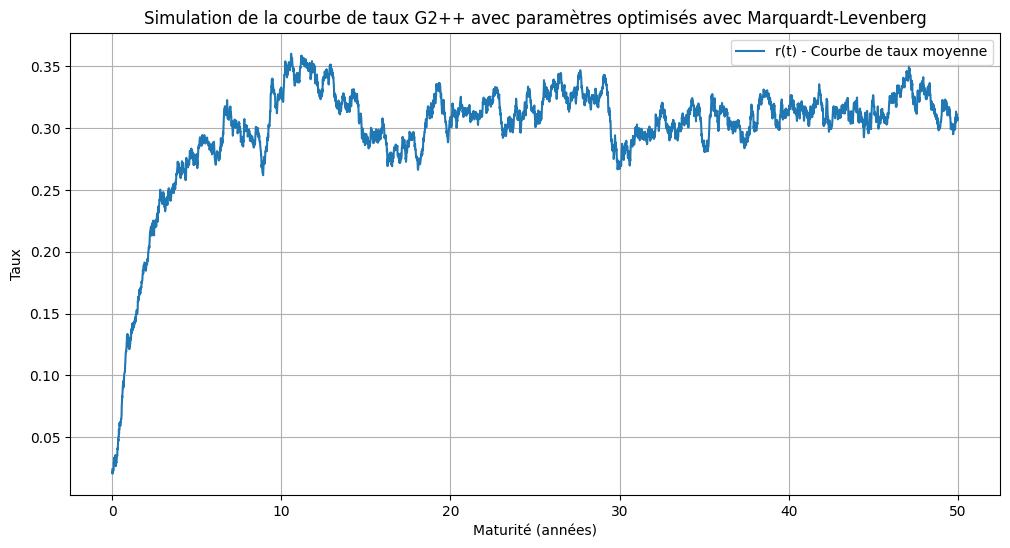

In [182]:
#Courbe des taux résultante
list_taux = []
a = optimized_params[0]
b = optimized_params[1]
sigma = optimized_params[2]
eta = optimized_params[3]
rho = optimized_params[4] if optimized_params[4] > -1 else -0.99

# Simulation 1000 fois des processus x(t) et y(t) avec les paramètres optimisés
for i in range (1000):
    x_optimized = np.zeros(N + 1)
    y_optimized = np.zeros(N + 1)

    for t in range(1, N + 1):
        W1_t = np.random.normal(0, 1)
        W2_t = rho * W1_t + np.sqrt(1 - rho**2) * np.random.normal(0, 1)
        x_optimized[t] = x_optimized[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * W1_t
        y_optimized[t] = y_optimized[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * W2_t

    # Simulation de theta(t) avec les paramètres optimisés
    theta_optimized = [r0]

    for t_idx, t in enumerate(t_grid[1:]):
        taux_forward = forward_rates[t_idx]
        df_dt = dr_dt_forward_values[t_idx]

        # Calcul des termes correctifs
        terme1 = (sigma**2 / (2 * a**2)) * ((1 - np.exp(- a * t))**2)
        terme2 = (eta**2 / (2 * b**2)) * ((1 - np.exp(- b * t))**2)
        terme3 = (rho * sigma * eta / (a + b)) * (1 - np.exp(- b * t)) * (1 - np.exp(- a * t))

        # Calcul de θ(t)
        theta_t =  taux_forward + terme1 + terme2 + terme3

        theta_optimized.append(theta_t)

    theta_optimized[0] = theta_optimized[1]

    # Calcul de la courbe de taux r(t) avec les paramètres optimisés
    r_optimized = {t : x_optimized[t_idx] + y_optimized[t_idx] + theta_optimized[t_idx] for t_idx, t in enumerate(t_grid)}
    list_taux.append(r_optimized)

# Affichage de la courbe de taux moyenne
plt.figure(figsize=(12, 6))
# Calcul de la courbe moyenne des taux
r_mean = {t : np.mean([taux[t] for taux in list_taux]) for t in t_grid}
plt.plot(list(r_mean.keys()), list(r_mean.values()), label='r(t) - Courbe de taux moyenne')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++ avec paramètres optimisés avec Marquardt-Levenberg')
plt.grid()
plt.show()


3) Calibrage par la méthode HJKB

## Test de martingalité

In [240]:
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, q_stat



a = optimized_params[0]

b = optimized_params[1]

sigma = optimized_params[2]

eta = optimized_params[3]

rho = optimized_params[4] if optimized_params[4] > -1 else -0.99

T=50

N=5000

dt=T/N

t_grid = np.linspace(0, T, N+1)

list_MT = []



def deflateur(t,r):

    times = [s for s in t_grid if s <= t] # Prendre les temps jusqu'à t

    integral = np.sum([r[s] * dt for s in times]) # Somme discrète de r(s) * dt

    return np.exp(-integral)



# Simulation 1000 fois des processus x(t) et y(t) avec les paramètres optimisés

for i in range (50):

    x_optimized = np.zeros(N + 1)

    y_optimized = np.zeros(N + 1)



    for t in range(1, N + 1):

        W1_t = np.random.normal(0, 1)

        W2_t = rho * W1_t + np.sqrt(1 - rho**2) * np.random.normal(0, 1)

        x_optimized[t] = x_optimized[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * W1_t

        y_optimized[t] = y_optimized[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * W2_t



        # Simulation de theta(t) avec les paramètres optimisés

        theta_optimized = [r0]



    for t_idx, t in enumerate(t_grid[1:]):

        taux_forward = forward_rates[t_idx]

        df_dt = dr_dt_forward_values[t_idx]



        # Calcul des termes correctifs

        terme1 = (sigma**2 / (2 * a**2)) * ((1 - np.exp(- a * t))**2)

        terme2 = (eta**2 / (2 * b**2)) * ((1 - np.exp(- b * t))**2)

        terme3 = (rho * sigma * eta / (a + b)) * (1 - np.exp(- b * t)) * (1 - np.exp(- a * t))



        # Calcul de θ(t)

        theta_t = taux_forward + terme1 + terme2 + terme3



        theta_optimized.append(theta_t)



        theta_optimized[0] = theta_optimized[1]



        # Calcul de la courbe de taux r(t) avec les paramètres optimisés

        r_optimized = {t : x_optimized[t_idx] + y_optimized[t_idx] + theta_optimized[t_idx] for t_idx, t in enumerate(t_grid)}

        deflateurs= {t : deflateur(t,r_optimized) for t in t_grid}

        zero_coupon_prices = {t: prix_zero_coupon(t, T, a, b, sigma, eta, rho, r_optimized) for t in t_grid}

        M = {t: deflateurs[t] * zero_coupon_prices[t] for t in t_grid}

        list_MT.append(M)










# Affichage de la courbe de taux moyenne

M_mean = {t : np.mean([Mar[t] for Mar in list_MT]) for t in t_grid}

first_key = next(iter(M_mean)) # Première clé du dictionnaire

first_value = M_mean[first_key] # Première valeur associée

plt.figure(figsize=(12, 6))

# Calcul de la courbe moyenne des taux



plt.plot(list(M_mean.keys()), list(M_mean.values()), label='r(t) - Courbe de taux moyenne')

plt.axhline(y=first_value, color='r', linestyle='--', label="Valeur initiale")

plt.xlabel('Maturité (années)')

plt.ylabel('E[Mt]')

plt.legend()

plt.title('Simulation de E[Mt] avec paramètres optimisés avec Marquardt-Levenberg')

plt.grid()

plt.show()



# Test de Dickey-Fuller (stationnarité)

#adf_test = adfuller(M_mean)

#print(f"Test de Dickey-Fuller : p-value = {adf_test[1]}")



# Test de Ljung-Box (autocorrélation des résidus)

#q_lb, p_values = q_stat(acf(M_mean, nlags=10, fft=False)[1:], len(M_mean))

#print(f"Test de Ljung-Box : p-value = {p_values[-1]}")

IndexError: list index out of range